# 0. Set Up

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from tqdm import tqdm
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score
)
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import StratifiedKFold, cross_val_score
import xgboost as xgb

In [34]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
%ls /content/drive/MyDrive/Reto_Telefonica/All_3_csv/Con_label_peruano/

500argentino_dataset_features_real.csv
500argentino_dataset_features_sintetico.csv
500chileno_dataset_features_real.csv
500chileno_dataset_features_sintetico.csv
500colombiano_dataset_features_real.csv
500colombiano_dataset_features_sintetico.csv


In [36]:
# Ruta de la carpeta Dany
ruta_base = "/content/drive/MyDrive/Reto_Telefonica/All_3_csv/Con_label_peruano/"

In [37]:
# Buscar todos los CSV
archivos = glob.glob(ruta_base + "*.csv")

print("CSV encontrados:")
for a in archivos:
    print(a)

dfs = []

for archivo in archivos:

    # Leer CSV
    df = pd.read_csv(archivo)

    # Nombre del archivo
    nombre = os.path.basename(archivo).lower().strip()

    # LABEL

    if "real" in nombre:
        df["label"] = 0
    else:
        df["label"] = 1

    # ACCENT
    if "peruano" in nombre:
        df["accent"] = "peruano"

    elif "colombiano" in nombre:
        df["accent"] = "colombiano"

    elif "chileno" in nombre:
        df["accent"] = "chileno"

    elif "argentino" in nombre:
        df["accent"] = "argentino"

    else:
        df["accent"] = "desconocido"
        print("No se detectó acento en:", nombre)

    # GENERO
    if "genero_f" in df.columns:

        df["genero"] = np.where(
            df["genero_f"] == 1,
            "femenino",
            "masculino"
        )

    else:

        print("Warning: 'genero_f' no encontrada")
        df["genero"] = "unknown"

    # MODELO GENERADOR

    df["modelo_generador"] = "real"

    # Solo aplicar a sintéticos
    if df["label"].iloc[0] == 1:

        archivo_lower = df["archivo"].astype(str).str.lower()

        df.loc[
            archivo_lower.str.contains("tts-stargan", na=False),
            "modelo_generador"
        ] = "TTS-StarGAN"

        df.loc[
            archivo_lower.str.contains("tts-diff", na=False),
            "modelo_generador"
        ] = "TTS-Diff"

        df.loc[
            archivo_lower.str.contains("cyclegan", na=False),
            "modelo_generador"
        ] = "CycleGAN"

        df.loc[
            archivo_lower.str.contains("stargan", na=False)
            & ~archivo_lower.str.contains("tts-stargan", na=False),
            "modelo_generador"
        ] = "StarGAN"

        df.loc[
            archivo_lower.str.contains("diff", na=False)
            & ~archivo_lower.str.contains("tts-dif", na=False),
            "modelo_generador"
        ] = "Diff"

        df.loc[
            archivo_lower.str.contains("tts", na=False)
            & ~archivo_lower.str.contains("tts-stargan", na=False)
            & ~archivo_lower.str.contains("tts-dif", na=False),
            "modelo_generador"
        ] = "TTS"

    # Guardar dataframe
    dfs.append(df)

# UNIR TODO
df_unified = pd.concat(dfs, ignore_index=True)

print("\nShape final:")
print(df_unified.shape)

df_unified.head()



CSV encontrados:
/content/drive/MyDrive/Reto_Telefonica/All_3_csv/Con_label_peruano/500colombiano_dataset_features_sintetico.csv
/content/drive/MyDrive/Reto_Telefonica/All_3_csv/Con_label_peruano/500chileno_dataset_features_sintetico.csv
/content/drive/MyDrive/Reto_Telefonica/All_3_csv/Con_label_peruano/500colombiano_dataset_features_real.csv
/content/drive/MyDrive/Reto_Telefonica/All_3_csv/Con_label_peruano/500chileno_dataset_features_real.csv
/content/drive/MyDrive/Reto_Telefonica/All_3_csv/Con_label_peruano/500argentino_dataset_features_sintetico.csv
/content/drive/MyDrive/Reto_Telefonica/All_3_csv/Con_label_peruano/500argentino_dataset_features_real.csv

Shape final:
(3000, 592)


,id_audio,archivo,label,genero_f,colombiano,chileno,argentino,peruano,modelo_cyclegan,modelo_diff,...,rolloff_median,rolloff_q1,rolloff_q3,rolloff_skew,rolloff_kurtosis,rolloff_mode,rolloff_iqr,accent,genero,modelo_generador
0,1,CycleGAN-cof_02436_00052210902-cof_00610_01846...,1,1,1,0,0,0,1,0,...,4183.59375,2037.109375,5710.937500,0.000705,-1.505250,1085.9375,3673.828125,colombiano,femenino,CycleGAN
1,2,CycleGAN-cof_02436_00052210902-cof_02484_00619...,1,1,1,0,0,0,1,0,...,5492.18750,2152.343750,6203.125000,-0.451915,-1.419164,6304.6875,4050.781250,colombiano,femenino,CycleGAN
2,3,CycleGAN-cof_02436_00052210902-cof_06136_01525...,1,1,1,0,0,0,1,0,...,4785.15625,1904.296875,5697.265625,-0.246978,-1.474301,1773.4375,3792.968750,colombiano,femenino,CycleGAN
3,4,CycleGAN-cof_02436_00052210902-cof_08784_01299...,1,1,1,0,0,0,1,0,...,4789.06250,1978.515625,5585.937500,-0.261644,-1.407339,5585.9375,3607.421875,colombiano,femenino,CycleGAN
4,5,CycleGAN-cof_02436_00301724065-cof_00610_00648...,1,1,1,0,0,0,1,0,...,4882.81250,2437.500000,5671.875000,-0.298326,-1.346327,1468.7500,3234.375000,colombiano,femenino,CycleGAN


In [38]:
df_unified["modelo_generador"].unique()

array(['CycleGAN', 'Diff', 'StarGAN', 'TTS-Diff', 'TTS-StarGAN', 'TTS',
       'real'], dtype=object)

# 1. Exploración de datos

In [39]:
# Paleta azul y morado
PALETTE = ["#3B82F6", "#800080"]

# Estilo general
sns.set_style("whitegrid")

In [40]:
# Informacion general
print("\nInformacion del dataset:")
df_unified.info()

# Dimensiones del dataset
print("\nShape del dataset:")
print(df_unified.shape)

# Valores nulos
print("\nValores nulos por columna:")
display(df_unified.isnull().sum())

# Estadisticas descriptivas
print("\nEstadisticas descriptivas:")
display(df_unified.describe())

# Variables categoricas
print("\nVariables categoricas:")
display(df_unified.describe(include='object'))

# Valores duplicados
print("\nValores duplicados:")
print(df_unified.duplicated().sum())

# Distribucion de clases
print("\nDistribucion REAL vs IA:")
display(df_unified["label"].value_counts())

# Distribucion por acento
print("\nDistribucion por acento:")
display(df_unified["accent"].value_counts())

# Distribucion cruzada
print("\nDistribucion acento vs label:")
display(pd.crosstab(df_unified["accent"], df_unified["label"]))


Informacion del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Columns: 592 entries, id_audio to modelo_generador
dtypes: float64(575), int64(13), object(4)
memory usage: 13.5+ MB

Shape del dataset:
(3000, 592)

Valores nulos por columna:


,0
id_audio,0
archivo,0
label,0
genero_f,0
colombiano,0
...,...
rolloff_mode,0
rolloff_iqr,0
accent,0
genero,0



Estadisticas descriptivas:


,id_audio,label,genero_f,colombiano,chileno,argentino,peruano,modelo_cyclegan,modelo_diff,modelo_stargan,...,rolloff_std,rolloff_min,rolloff_max,rolloff_median,rolloff_q1,rolloff_q3,rolloff_skew,rolloff_kurtosis,rolloff_mode,rolloff_iqr
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.0,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,250.500000,0.500000,0.443000,0.333333,0.333333,0.333333,0.0,0.090000,0.160000,0.090000,...,1768.918627,510.703125,7039.507812,3817.763021,2208.783203,5152.961589,-0.009013,-0.893887,3181.747396,2944.178385
std,144.361341,0.500083,0.496823,0.471483,0.471483,0.471483,0.0,0.286229,0.366667,0.286229,...,252.323507,346.585000,432.495746,1024.487929,665.075224,748.585853,0.579815,0.712626,1916.753966,860.570244
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,951.699335,85.937500,4328.125000,906.250000,501.953125,2121.093750,-2.118632,-1.787087,109.375000,464.843750
25%,125.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,1599.769704,187.500000,6835.937500,2932.617188,1769.531250,4770.996094,-0.367461,-1.382898,1492.187500,2428.710938
50%,250.500000,0.500000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,1778.638771,453.125000,7117.187500,3791.015625,2101.562500,5273.437500,-0.026167,-1.102165,2648.437500,3031.250000
75%,375.250000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.000000,0.000000,0.000000,...,1955.112855,734.375000,7335.937500,4644.531250,2508.300781,5687.500000,0.349103,-0.635696,5125.000000,3531.250000
max,500.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,...,2493.051114,2273.437500,7843.750000,6171.875000,5429.687500,7140.625000,1.853568,3.848599,7515.625000,5162.109375



Variables categoricas:


...

,count
label,
1,1500
0,1500



Distribucion por acento:


,count
accent,
colombiano,1000
chileno,1000
argentino,1000



Distribucion acento vs label:


label,0,1
accent,,
argentino,500,500
chileno,500,500
colombiano,500,500


In [41]:
df_unified.isna().sum().sort_values(ascending=False).head(20)

,0
flatness_kurtosis,0
flatness_skew,0
flatness_q3,0
flatness_q1,0
flatness_median,0
flatness_max,0
flatness_min,0
flatness_std,0
flatness_mean,0
contrast_7_iqr,0


## 1.1. Distribucion por acento y clase

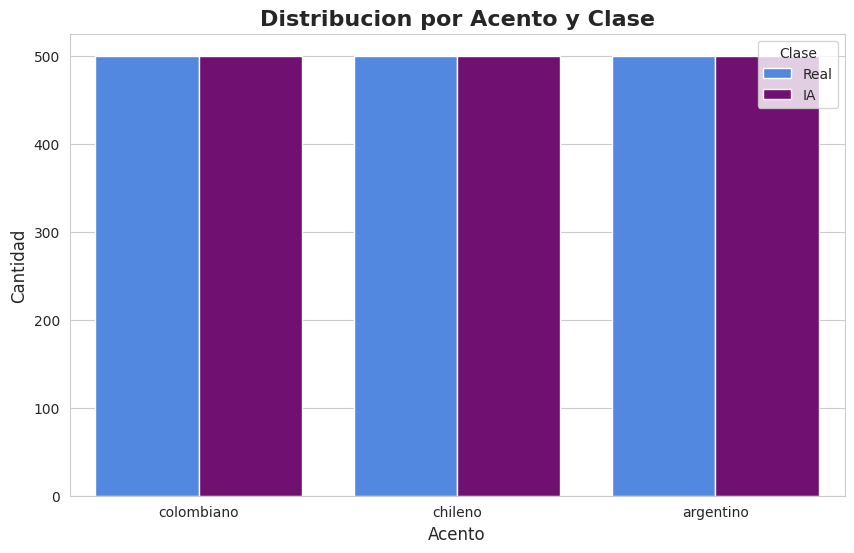

In [42]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df_unified,
    x="accent",
    hue="label",
    palette=PALETTE
)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Real", "IA"], title="Clase")

plt.title("Distribucion por Acento y Clase", fontsize=16, fontweight="bold")
plt.xlabel("Acento", fontsize=12)
plt.ylabel("Cantidad", fontsize=12)

plt.show()

## 1.2. Histograma RMS

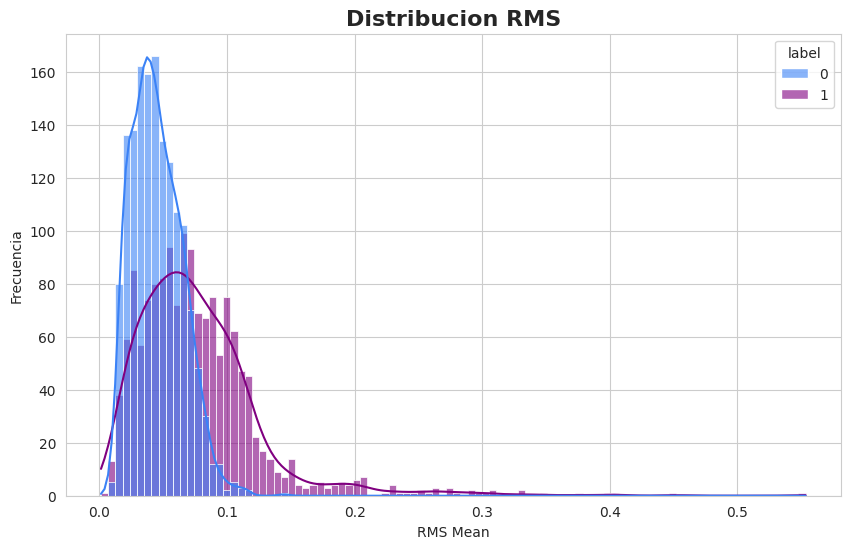

In [43]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df_unified,
    x="rms_mean",
    hue="label",
    kde=True,
    palette=PALETTE,
    alpha=0.6
)

plt.title("Distribucion RMS", fontsize=16, fontweight="bold")
plt.xlabel("RMS Mean")
plt.ylabel("Frecuencia")

plt.show()

La gráfica analiza la distribución de RMS Mean, una feature que mide la energía promedio del audio. Esta característica es importante porque las voces sintéticas suelen tener patrones de intensidad más uniformes, mientras que las voces reales presentan variaciones naturales en volumen y entonación.
En los resultados se observa que los audios reales (0) se concentran en valores más bajos y compactos, mientras que los audios generados por IA (1) tienen una distribución más dispersa y alcanzan valores de energía más altos. Esto indica que el RMS puede ayudar a diferenciar ambas clases, aunque existe superposición entre ellas, por lo que debe combinarse con otras features acústicas para lograr una mejor detección.

## 1.3. Histograma ZCR

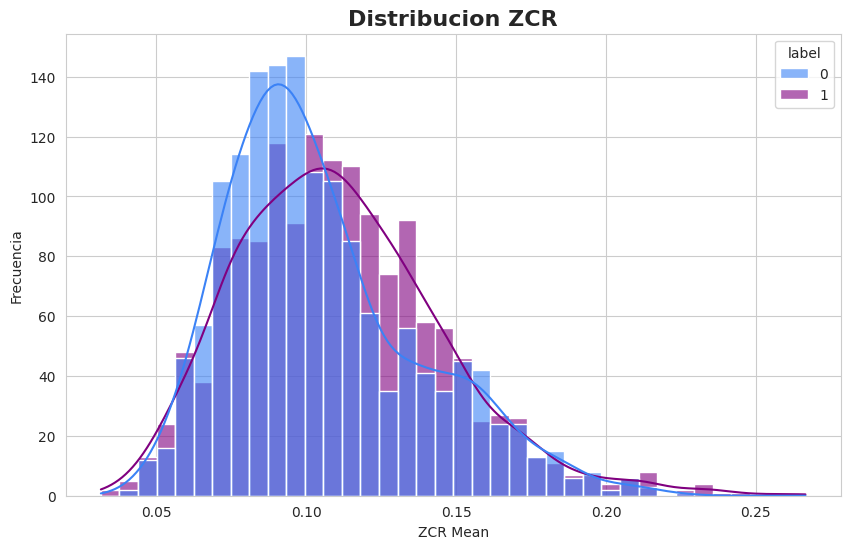

In [44]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df_unified,
    x="zcr_mean",
    hue="label",
    kde=True,
    palette=PALETTE,
    alpha=0.6
)

plt.title("Distribucion ZCR", fontsize=16, fontweight="bold")
plt.xlabel("ZCR Mean")
plt.ylabel("Frecuencia")

plt.show()

La gráfica muestra la distribución de ZCR Mean (Zero Crossing Rate), una feature que mide cuántas veces la señal de audio cambia de signo. Esta característica es útil porque refleja la complejidad y variabilidad de la señal, aspectos que pueden diferenciar voces humanas de voces sintéticas.
En los resultados se observa que los audios reales (0) tienden a concentrarse en valores ligeramente más bajos, mientras que los audios generados por IA (1) presentan una distribución desplazada hacia valores mayores de ZCR. Esto sugiere que las voces sintéticas podrían contener patrones de frecuencia o ruido más irregulares.
Sin embargo, existe una superposición considerable entre ambas clases, por lo que el ZCR por sí solo no separa completamente los audios reales y sintéticos, aunque sí aporta información relevante cuando se combina con otras features acústicas.

## 1.4. Boxplot MFCC

/tmp/ipykernel_39906/3702633454.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


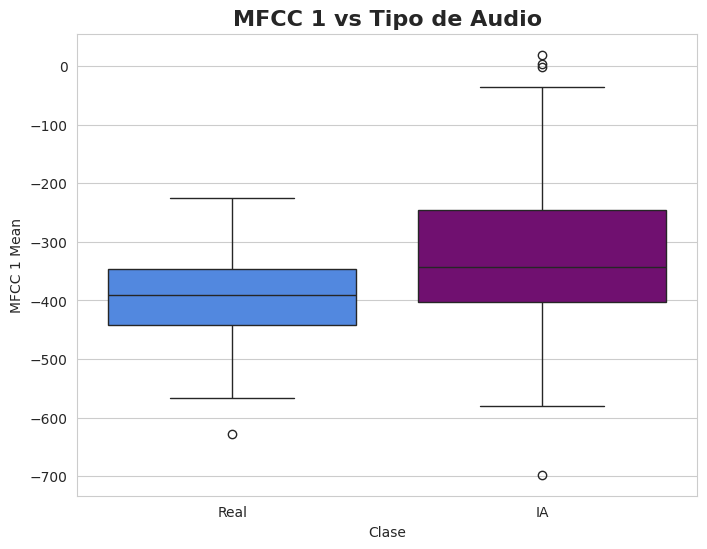

In [45]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_unified,
    x="label",
    y="mfcc_1_mean",
    palette=PALETTE
)

plt.xticks([0,1], ["Real", "IA"])

plt.title("MFCC 1 vs Tipo de Audio", fontsize=16, fontweight="bold")
plt.xlabel("Clase")
plt.ylabel("MFCC 1 Mean")

plt.show()

La gráfica compara la distribución de MFCC 1 Mean entre audios reales y generados por IA. Los MFCC (Mel Frequency Cepstral Coefficients) son una de las features más utilizadas en procesamiento de audio, ya que representan características espectrales relacionadas con la forma y el timbre de la voz.

En este caso, se observa que los audios sintéticos (IA) presentan una mayor dispersión y valores generalmente más altos que los audios reales. Por otro lado, las voces reales muestran una distribución más concentrada.

Esto sugiere que el primer coeficiente MFCC está capturando diferencias acústicas relevantes entre ambos tipos de audio, posiblemente relacionadas con patrones espectrales más artificiales en las voces sintetizadas. Aun así, existe superposición entre clases, por lo que esta feature debe complementarse con otras para mejorar la capacidad de detección.

## 1.5. Boxplot RMS (Outliers)

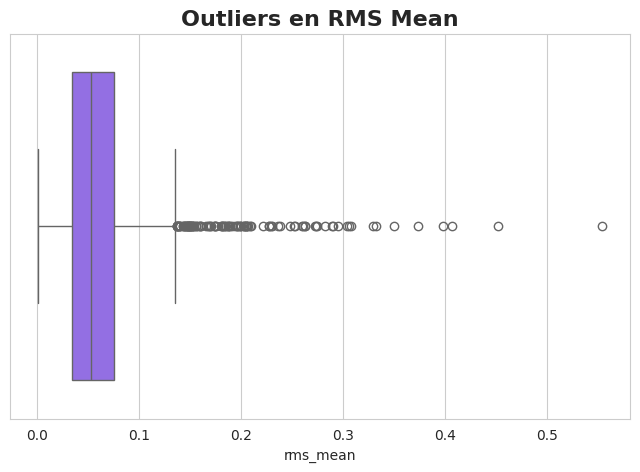

In [46]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df_unified["rms_mean"],
    color="#8B5CF6"
)

plt.title("Outliers en RMS Mean", fontsize=16, fontweight="bold")

plt.show()

La gráfica muestra los outliers presentes en la feature RMS Mean, que representa la energía promedio del audio. Este análisis se realiza para identificar valores extremos que podrían corresponder a audios atípicos, grabaciones con demasiado ruido, silencios o diferencias de volumen muy marcadas.

Se observa que la mayoría de los audios se concentran en valores bajos de RMS, mientras que existen varios outliers con niveles de energía considerablemente más altos. Esto indica que algunos audios presentan características acústicas muy diferentes al resto del dataset.

Detectar estos outliers es importante porque pueden afectar el entrenamiento del modelo, haciendo que aprenda patrones relacionados con volumen o calidad de grabación en lugar de enfocarse únicamente en las diferencias entre voces reales y sintéticas.

## 1.6. Boxplot RMS (Outliers)

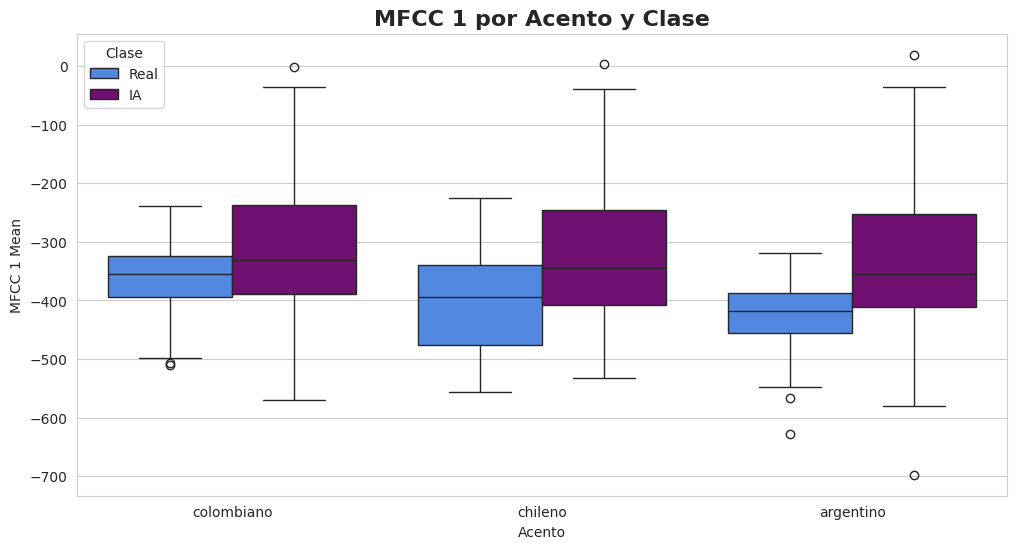

In [47]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_unified,
    x="accent",
    y="mfcc_1_mean",
    hue="label",
    palette=PALETTE
)

plt.title("MFCC 1 por Acento y Clase", fontsize=16, fontweight="bold")
plt.xlabel("Acento")
plt.ylabel("MFCC 1 Mean")

handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ["Real", "IA"], title="Clase")

plt.show()

La gráfica compara la distribución de MFCC 1 Mean según el acento y el tipo de audio (real o IA). Este análisis permite verificar si las diferencias observadas provienen realmente de la síntesis de voz o si el modelo podría estar aprendiendo patrones asociados al acento.
En los tres acentos se observa una tendencia similar: los audios generados por IA presentan una mayor dispersión y valores más altos de MFCC 1 en comparación con los audios reales. Esto indica que la feature logra capturar diferencias relacionadas con la generación sintética de voz de manera relativamente consistente entre acentos.
Sin embargo, también existen diferencias entre colombiano, chileno y argentino, lo que confirma que el acento influye en las características acústicas del dataset. Por ello, es importante considerar esta variable durante el entrenamiento y evaluación del modelo para evitar sesgos y asegurar que el sistema aprenda a detectar síntesis de voz y no únicamente diferencias de pronunciación o entonación.

## 1.7. PCA Visualization

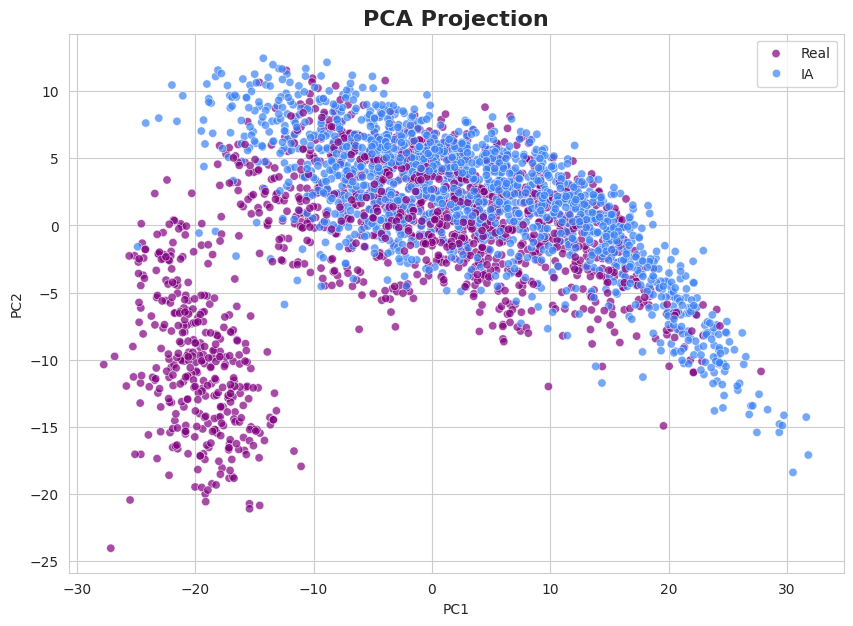

In [48]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

X = df_unified.select_dtypes(include=['float64', 'int64'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["label"] = df_unified["label"]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="label",
    palette=PALETTE,
    alpha=0.7
)

plt.title("PCA Projection", fontsize=16, fontweight="bold")

plt.legend(labels=["Real", "IA"])

plt.show()

La visualización PCA permite reducir todas las features acústicas del dataset a dos componentes principales (PC1 y PC2) para observar de forma gráfica cómo se distribuyen los audios reales y sintéticos. Este análisis es útil para identificar si las features extraídas contienen información suficiente para diferenciar ambas clases.
En el gráfico se observa una separación parcial entre los audios reales y los generados por IA. Los audios sintéticos presentan una mayor concentración en ciertas regiones del espacio, mientras que los audios reales muestran agrupaciones más dispersas, especialmente en la zona izquierda inferior del gráfico.
Sin embargo, también existe una superposición considerable entre ambas clases, lo que indica que algunas voces sintéticas comparten características acústicas similares a las voces reales. Esto sugiere que las features utilizadas sí capturan diferencias relevantes, aunque no son suficientes para lograr una separación perfecta por sí solas.

## 1.8. PCA por acento

<Axes: xlabel='PC1', ylabel='PC2'>

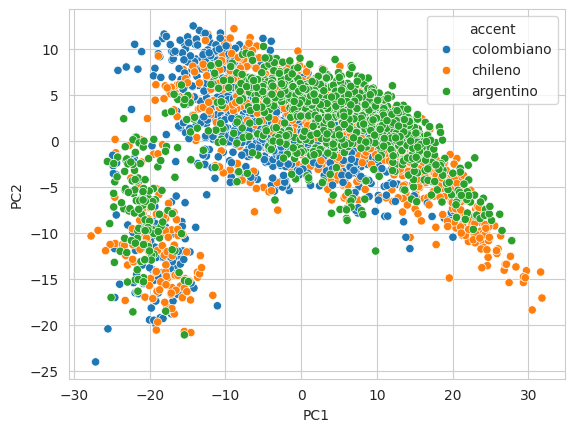

In [49]:
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue=df_unified["accent"]
)

En el gráfico se observa que los acentos presentan ciertas agrupaciones y tendencias dentro del espacio generado por PCA, especialmente en algunas regiones donde predomina un acento sobre los demás. Esto indica que las features utilizadas, como MFCC y características espectrales, también capturan información relacionada con la pronunciación y entonación propias de cada país.

Sin embargo, los grupos no están completamente separados y existe bastante superposición entre ellos, lo que sugiere que el dataset mantiene cierta diversidad y no depende únicamente del acento. Aun así, este resultado confirma la importancia de considerar la variable de acento durante el entrenamiento y evaluación del modelo para evitar sesgos y asegurar que el sistema aprenda patrones de síntesis de voz y no únicamente diferencias dialectales.

## 1.9. PCA por genero

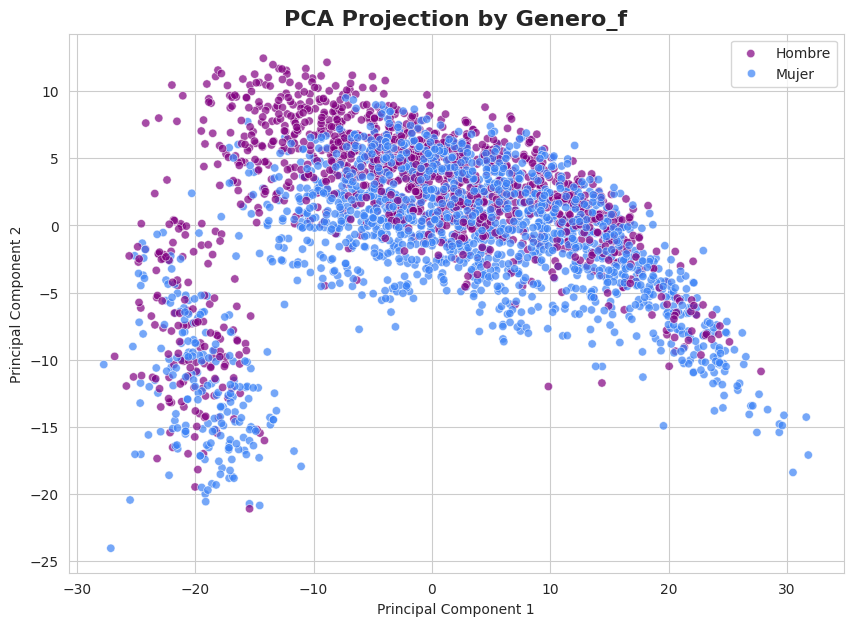

In [50]:
pca_df_genero = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df_genero["genero_f"] = df_unified["genero_f"]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df_genero,
    x="PC1",
    y="PC2",
    hue="genero_f",
    palette=PALETTE,
    alpha=0.7
)

plt.title("PCA Projection by Genero_f", fontsize=16, fontweight="bold")
plt.legend(labels=["Hombre", "Mujer"]) # Assuming 0 for Hombre, 1 for Mujer based on previous usage
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

Hay una separación parcial, con las voces masculinas tendiendo hacia valores mayores del PC2, apesar de ello, los puntos de ambos géneros están en gran medida entremezclados, lo que sugiere que el género por sí solo, no conduce a perfiles acústicos claramente distintos.

## 1.10. Medias de las MFCC por tipo de audio

MFCC 1: La Energía (El volumen)

MFCC 2 al 4: La Forma "Gruesa" (Timbre y Fonemas)
Estos son los más importantes para identificar qué se está diciendo y quién habla. Representan las variaciones de baja frecuencia en el espectro.

MFCC 2: Representa el balance entre frecuencias bajas y altas.

MFCC 3 y 4: Están muy relacionados con los formantes (las resonancias de tu boca al decir letras como la "A" o la "U").

*Los modelos de IA suelen ser muy buenos replicando estos porque son esenciales para que la voz se entienda.*

MFCC 5 al 8: Detalles de Resonancia
Estos capturan cambios más finos en el espectro. Describen matices de la garganta y la posición de la lengua.

*Aquí es donde la IA empieza a tener problemas. A veces, los sintetizadores generan resonancias "metálicas" o demasiado perfectas que se reflejan en estos coeficientes intermedios.*

MFCC 9 al 12: Detalles de Alta Frecuencia (Artefactos de la IA)
Estos representan variaciones muy rápidas y finas en el espectro de frecuencias.

*Capturan texturas sutiles, como el aire al pronunciar una "S" o pequeñas irregularidades en la voz humana. La mayoría de los modelos de IA (especialmente los más antiguos o ligeros) fallan en replicar la complejidad de las altas frecuencias*

In [51]:
mfcc_mean_cols = [col for col in df_unified.columns if col.startswith('mfcc_') and col.endswith('_mean')]

# Group by label and calculate the mean for each MFCC column
mfcc_means_table = df_unified.groupby('label')[mfcc_mean_cols].mean()

# Rename the index for better readability
mfcc_means_table.index = mfcc_means_table.index.map({0: 'Real', 1: 'IA'})

# Transpose the table
mfcc_means_table_transposed = mfcc_means_table.T

# Add a new column with the difference between 'Real' and 'IA' means
mfcc_means_table_transposed['Difference (Real - IA)'] = mfcc_means_table_transposed['Real'] - mfcc_means_table_transposed['IA']

# Add a new column with the percentage difference relative to 'Real'
mfcc_means_table_transposed['Percentage Diff (vs Real)'] = (((mfcc_means_table_transposed['Real'] - mfcc_means_table_transposed['IA']) / mfcc_means_table_transposed['Real']) * 100).map('{:.2f}%'.format)

print("Tabla de Medias de MFCC por Tipo de Audio (Transpuesta con Diferencia y %):")
display(mfcc_means_table_transposed)

Tabla de Medias de MFCC por Tipo de Audio (Transpuesta con Diferencia y %):


label,Real,IA,Difference (Real - IA),Percentage Diff (vs Real)
mfcc_1_mean,-395.787623,-329.292935,-66.494688,16.80%
mfcc_2_mean,67.342328,70.711925,-3.369597,-5.00%
mfcc_3_mean,1.687080,-0.179509,1.866589,110.64%
mfcc_4_mean,17.481129,17.925248,-0.444119,-2.54%
mfcc_5_mean,5.770021,2.573480,3.196541,55.40%
mfcc_6_mean,1.334783,-1.659526,2.994308,224.33%
mfcc_7_mean,-1.712239,-4.342789,2.630549,-153.63%
mfcc_8_mean,-5.830043,-9.025333,3.195291,-54.81%
mfcc_9_mean,-1.702828,-4.008414,2.305586,-135.40%
mfcc_10_mean,-0.603662,-4.739763,4.136101,-685.17%


# 2. Random Forest con Cross Validation

In [52]:
# Eliminamos columnas de metadatos para evitar sesgos o biased
df_model = df_unified.copy()

columnas_a_eliminar = [
    "label",
    "archivo",
    "id_audio",
    "accent",
    "colombiano",
    "chileno",
    "argentino",
    "peruano",
    "modelo_cyclegan",
    "modelo_diff",
    "modelo_stargan",
    "modelo_tts_dif",
    "modelo_tts_stargan",
    "modelo_tts",
    "genero_f",
    "genero",
    "modelo_generador"
]

X = df_model.drop(columns=columnas_a_eliminar, errors="ignore")

y = df_model["label"]

# Verificar columnas restantes
print("Columnas restantes:")
print(X.columns)

# Ver primeras filas
print("\nPrimeras filas de X:")
display(X.head())

# Ver target
print("\nPrimeras filas de y:")
display(y.head())

Columnas restantes:
Index(['duracion_seg', 'zcr_mean', 'zcr_std', 'zcr_min', 'zcr_max',
       'zcr_median', 'zcr_q1', 'zcr_q3', 'zcr_skew', 'zcr_kurtosis',
       ...
       'rolloff_std', 'rolloff_min', 'rolloff_max', 'rolloff_median',
       'rolloff_q1', 'rolloff_q3', 'rolloff_skew', 'rolloff_kurtosis',
       'rolloff_mode', 'rolloff_iqr'],
      dtype='object', length=575)

Primeras filas de X:


,duracion_seg,zcr_mean,zcr_std,zcr_min,zcr_max,zcr_median,zcr_q1,zcr_q3,zcr_skew,zcr_kurtosis,...,rolloff_std,rolloff_min,rolloff_max,rolloff_median,rolloff_q1,rolloff_q3,rolloff_skew,rolloff_kurtosis,rolloff_mode,rolloff_iqr
0,4.000,0.169317,0.078172,0.052246,0.353516,0.171875,0.092407,0.230835,0.269125,-0.991107,...,1971.536037,789.0625,7562.5000,4183.59375,2037.109375,5710.937500,0.000705,-1.505250,1085.9375,3673.828125
1,5.184,0.157358,0.097120,0.021973,0.387207,0.164551,0.059814,0.239014,0.258923,-1.104590,...,2080.871242,554.6875,7539.0625,5492.18750,2152.343750,6203.125000,-0.451915,-1.419164,6304.6875,4050.781250
2,5.088,0.138239,0.082688,0.011230,0.337891,0.135986,0.058350,0.201050,0.402994,-0.845064,...,1965.394736,585.9375,7531.2500,4785.15625,1904.296875,5697.265625,-0.246978,-1.474301,1773.4375,3792.968750
3,5.088,0.142661,0.081041,0.012695,0.334473,0.148682,0.064575,0.208374,0.281198,-0.969667,...,1887.489328,601.5625,7468.7500,4789.06250,1978.515625,5585.937500,-0.261644,-1.407339,5585.9375,3607.421875
4,2.688,0.151252,0.088039,0.033203,0.381348,0.108398,0.076172,0.212402,0.689315,-0.455638,...,1878.109702,351.5625,7281.2500,4882.81250,2437.500000,5671.875000,-0.298326,-1.346327,1468.7500,3234.375000



Primeras filas de y:


,label
0,1
1,1
2,1
3,1
4,1


## 2.1. Primer entrenamiendo de Random Forest

In [53]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42, #Reproducibilidad
    n_jobs=-1 #Utiliza toda la CPU
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Accuracy por fold:")
print(scores)

print("Accuracy promedio:")
print(np.mean(scores))

print("Desviacion estandar:")
print(np.std(scores))

Accuracy por fold:
[0.97833333 0.96833333 0.965      0.96333333 0.96333333]
Accuracy promedio:
0.9676666666666666
Desviacion estandar:
0.005637178175095933


# 3. Crear y entrenar Random Forest con Train/Test Split

In [54]:
# TRAIN / TEST SPLIT
# Se divide el dataset en:
# - entrenamiento (80%)
# - prueba (20%)
#
# stratify=y mantiene balanceadas
# las clases en ambos conjuntos

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Shape Train:")
print(X_train.shape)

print("\nShape Test:")
print(X_test.shape)

Shape Train:
(2400, 575)

Shape Test:
(600, 575)


In [55]:
# RANDOM FOREST
# Se crea el modelo con:

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Entrenamiento del modelo
rf_model.fit(X_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [56]:
# PREDICCIONES
# El modelo predice las clases
# del conjunto de prueba

y_pred = rf_model.predict(X_test)

print("Predicciones realizadas")

Predicciones realizadas


In [57]:
# CLASSIFICATION REPORT

report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       300
           1       0.97      0.95      0.96       300

    accuracy                           0.96       600
   macro avg       0.96      0.96      0.96       600
weighted avg       0.96      0.96      0.96       600



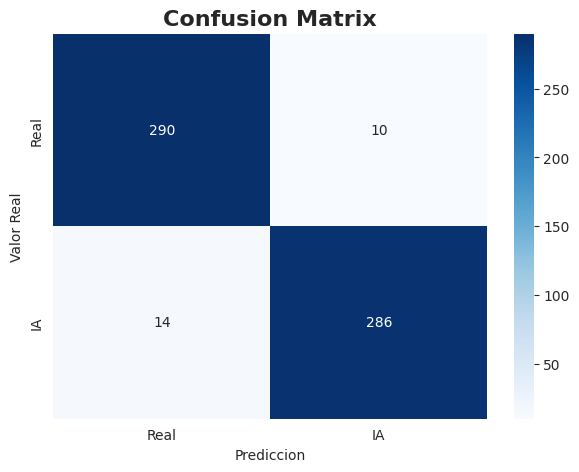

In [58]:
# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Prediccion")
plt.ylabel("Valor Real")

plt.xticks([0.5, 1.5], ["Real", "IA"])
plt.yticks([0.5, 1.5], ["Real", "IA"])

plt.show()

In [59]:
# FEATURE IMPORTANCE

importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

print("Top 15 features mas importantes:")

display(feature_importance_df.head(15))

Top 15 features mas importantes:


,feature,importance
536,contrast_6_q1,0.033965
471,bandwidth_q3,0.030187
570,rolloff_q3,0.024196
23,rmse_manual,0.021698
533,contrast_6_min,0.019465
15,rms_max,0.019254
540,contrast_6_mode,0.019156
27,mfcc_1_min,0.018869
18,rms_q3,0.018446
30,mfcc_1_q1,0.017431


/tmp/ipykernel_39906/2110500919.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


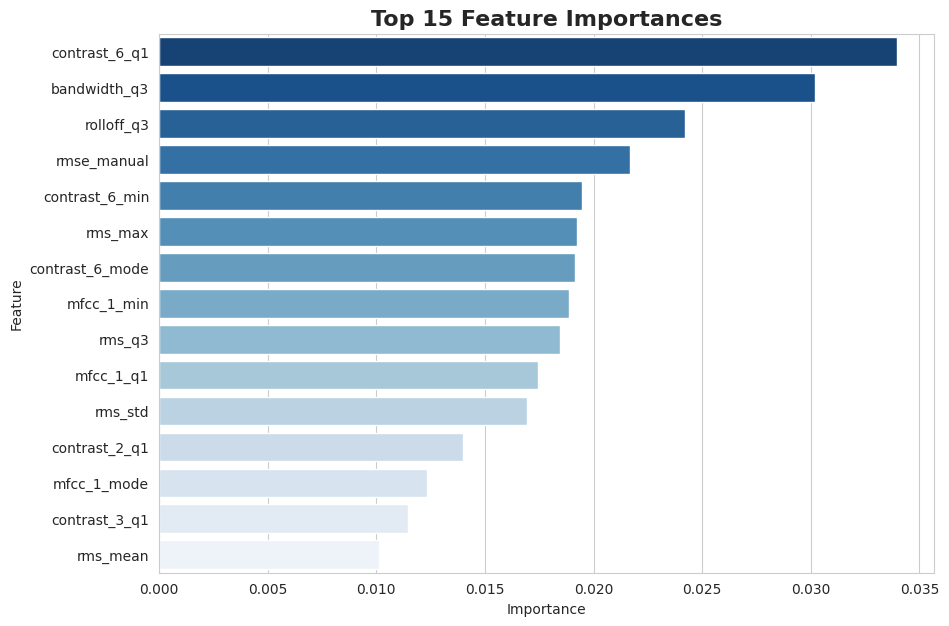

In [60]:
# GRAFICA FEATURE IMPORTANCE

top_features = feature_importance_df.head(15)

plt.figure(figsize=(10,7))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature",
    palette="Blues_r"
)

plt.title(
    "Top 15 Feature Importances",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## 3.1. Recall por acentos

En seguridad y detección de spoofing, el Recall suele ser mucho más importante que el Accuracy (Que tan seguido acierta el modelo ene general). Queremos minimizar los "Falsos Negativos" (audios sintéticos que el modelo cree que son reales).

In [61]:
# 1. Preparación de datos
accent_values = df_unified["accent"]

# 2. Split Sincronizado
# Re-ejecutamos el split para que accent_test coincida con X_test e y_test
X_train, X_test, y_train, y_test, accent_train, accent_test = train_test_split(
    X, y, accent_values, test_size=0.2, stratify=y, random_state=42
)

# 3. Predicciones
y_pred = rf_model.predict(X_test)

# 4. Crear DataFrame de resultados
results_accent_df = pd.DataFrame({
    "accent": accent_test,
    "real": y_test,
    "pred": y_pred
})

print("=== ANÁLISIS DE RECALL POR ACENTO (DETECCIÓN DE SINTÉTICOS) ===\n")

# Definimos cuál es tu etiqueta para audios sintéticos
etiqueta_sintetico = 1

# Iteramos para mostrar el reporte completo por cada acento
for acc in results_accent_df["accent"].unique():
    subset = results_accent_df[results_accent_df["accent"] == acc]

    rec_sintetico = recall_score(subset["real"], subset["pred"], pos_label=etiqueta_sintetico)

    print(f"--- Acento: {acc.upper()} ---")
    print(f"Cantidad de audios en test: {len(subset)}")
    print(f"Recall (Detección de Sintéticos): {rec_sintetico:.4f}")
    print("\nReporte detallado:")
    print(classification_report(subset["real"], subset["pred"]))
    print("-" * 40)

# 5. RESUMEN FINAL
# El parámetro 'include_groups=False' evita un Warning en versiones nuevas de Pandas
resumen_acentos = results_accent_df.groupby("accent").apply(
    lambda x: recall_score(x["real"], x["pred"], pos_label=etiqueta_sintetico),
    include_groups=False
).sort_values(ascending=False) # Lo ordenamos de mejor a peor recall

print("\nResumen de Recall (Sintéticos) por acento:")
print(resumen_acentos)

=== ANÁLISIS DE RECALL POR ACENTO (DETECCIÓN DE SINTÉTICOS) ===

--- Acento: COLOMBIANO ---
Cantidad de audios en test: 184
Recall (Detección de Sintéticos): 0.9149

Reporte detallado:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94        90
           1       0.97      0.91      0.94        94

    accuracy                           0.94       184
   macro avg       0.94      0.94      0.94       184
weighted avg       0.94      0.94      0.94       184

----------------------------------------
--- Acento: ARGENTINO ---
Cantidad de audios en test: 224
Recall (Detección de Sintéticos): 0.9633

Reporte detallado:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       115
           1       1.00      0.96      0.98       109

    accuracy                           0.98       224
   macro avg       0.98      0.98      0.98       224
weighted avg       0.98      0.98      0.98       224

-

## 3.2. Recall por genero

Este análisis es vital porque, históricamente, muchos modelos de audio han tenido mejor desempeño en voces masculinas que femeninas (o viceversa) debido a que las frecuencias fundamentales ($f_0$) son distintas.


In [64]:
# 1. Preparación de datos
# Extraemos la columna de género original
genero_values = df_unified["genero"]
y = df_unified["label"]

# Definimos las columnas a eliminar para el entrenamiento (X no debe ver el género)
columnas_a_eliminar = [
    "label", "archivo", "id_audio", "accent", "colombiano", "chileno","peruano",
    "argentino", "modelo_cyclegan", "modelo_diff", "modelo_stargan",
    "modelo_tts_dif", "modelo_tts_stargan", "modelo_tts", "genero", "genero_f", "modelo_generador"
]
X = df_unified.drop(columns=columnas_a_eliminar, errors="ignore")

# 2. Split Sincronizado (X, y, y GÉNERO)
# Mantenemos random_state=42 para consistencia con tus pruebas anteriores
X_train, X_test, y_train, y_test, gen_train, gen_test = train_test_split(
    X,
    y,
    genero_values,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 3. Predicciones
# Usamos el rf_model ya entrenado o lo re-entrenamos con el nuevo split
y_pred = rf_model.predict(X_test)

# 4. Crear DataFrame de resultados para facilitar el filtrado
results_gen_df = pd.DataFrame({
    "genero": gen_test,
    "real": y_test,
    "pred": y_pred
})

print("=== ANÁLISIS DE RECALL Y DESEMPEÑO POR GÉNERO ===\n")

# Iteramos sobre los valores únicos: 'femenino' y 'masculino'
for g in results_gen_df["genero"].unique():

    subset = results_gen_df[results_gen_df["genero"] == g]


    etiqueta_sintetico = 1

    rec_sintetico = recall_score(
        subset["real"],
        subset["pred"],
        pos_label=etiqueta_sintetico
    )

    print(f"--- Género: {g.upper()} ---")
    print(f"Cantidad de audios en test: {len(subset)}")
    print(f"Recall (Detección de audios sintéticos): {rec_sintetico:.4f}")
    print("\nReporte detallado:")
    print(classification_report(subset["real"], subset["pred"]))
    print("-" * 40)

# 5. Comparativa visual rápida
resumen = results_gen_df.groupby("genero").apply(
    lambda x: recall_score(x["real"], x["pred"], pos_label=etiqueta_sintetico),
    include_groups=False
).sort_values(ascending=False) # Lo ordenamos de mejor a peor recall
print("\nResumen de Recall (Sintéticos) por género:")
print(resumen)


=== ANÁLISIS DE RECALL Y DESEMPEÑO POR GÉNERO ===

--- Género: FEMENINO ---
Cantidad de audios en test: 264
Recall (Detección de audios sintéticos): 0.9624

Reporte detallado:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       131
           1       0.95      0.96      0.96       133

    accuracy                           0.95       264
   macro avg       0.95      0.95      0.95       264
weighted avg       0.95      0.95      0.95       264

----------------------------------------
--- Género: MASCULINO ---
Cantidad de audios en test: 336
Recall (Detección de audios sintéticos): 0.9461

Reporte detallado:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       169
           1       0.98      0.95      0.96       167

    accuracy                           0.96       336
   macro avg       0.96      0.96      0.96       336
weighted avg       0.96      0.96      0.96       336

---

El Recall para la clase "Sintético" es la métrica más crítica. Nos dice: "De todos los audios falsos que existían de mujeres, ¿cuántos logró atrapar realmente el modelo?".

Que el Recall es menor en mujeres podría deberse a que los modelos de síntesis de voz femenina suelen ser más complejos debido a que las frecuencias ($f_0$) son más altas y los errores de fase son más notorios, o quizás el modelo de Random Forest tiene dificultades con los tonos agudos.

Considerar agregar como característica el Pitch (F0) usando librosa.yin o librosa.pyin en el futuro para darle más herramientas al modelo.

## 3.2. Recall por modelo de generacion

Para analizar el Recall por modelo generador, debemos tener cuidado con un detalle lógico: los modelos generadores (CycleGAN, Diff, StarGAN, etc.) solo existen para los audios sintéticos. Los audios reales no tienen un "modelo generador" (o su valor suele ser NaN o None).

Este análisis nos dirá exactamente qué arquitectura de IA es la que está logrando engañar mejor a tu Random Forest.

In [67]:
# 1. Preparación de datos
# Extraemos la columna del modelo generador
modelos_values = df_unified["modelo_generador"]
y = df_unified["label"]

# Definimos las columnas a eliminar para el entrenamiento
columnas_a_eliminar = [
    "label", "archivo", "id_audio", "accent", "colombiano", "chileno","peruano",
    "argentino", "modelo_cyclegan", "modelo_diff", "modelo_stargan",
    "modelo_tts_dif", "modelo_tts_stargan", "modelo_tts", "genero", "genero_f",
    "modelo_generador"
]
X = df_unified.drop(columns=columnas_a_eliminar, errors="ignore")

# 2. Split Sincronizado (X, y, y MODELOS)
X_train, X_test, y_train, y_test, mod_train, mod_test = train_test_split(
    X,
    y,
    modelos_values,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 3. Predicciones
y_pred = rf_model.predict(X_test)

# 4. Crear DataFrame de resultados
results_mod_df = pd.DataFrame({
    "modelo_generador": mod_test,
    "real": y_test,
    "pred": y_pred
})

print("=== ANÁLISIS DE RECALL POR ARQUITECTURA GENERADORA ===\n")

etiqueta_sintetico = 1

# Filtramos los resultados para evaluar SOLO los audios sintéticos
# (Ya que el Recall se calcula sobre la clase positiva que queremos detectar)
solo_sinteticos = results_mod_df[results_mod_df["real"] == etiqueta_sintetico]

# Iteramos sobre cada modelo de IA (CycleGAN, StarGAN, Diff, etc.)
for m in solo_sinteticos["modelo_generador"].unique():
    # Si hay valores nulos (para audios reales), los saltamos en este loop
    if pd.isna(m) or m == "real" or m == "None":
        continue

    subset = solo_sinteticos[solo_sinteticos["modelo_generador"] == m]

    # Calculamos el recall manualmente: (aciertos donde predicho == real) / total de ese modelo
    aciertos = (subset["pred"] == etiqueta_sintetico).sum()
    rec_modelo = aciertos / len(subset)

    print(f"--- Modelo de IA: {m.upper()} ---")
    print(f"Audios evaluados: {len(subset)}")
    print(f"Recall (Detección exitosa): {rec_modelo:.4f}")
    print("-" * 40)

# 5. Resumen final ordenado
# Esto nos dirá qué modelo de IA es el más "peligroso" (el que tiene menor recall)
resumen_modelos = solo_sinteticos.groupby("modelo_generador").apply(
    lambda x: (x["pred"] == etiqueta_sintetico).mean(),
    include_groups=False
).sort_values(ascending=True) # Ordenado de menor a mayor para ver el más difícil primero

print("\nResumen de Recall por Arquitectura (Menor Recall = IA más difícil de detectar):")
print(resumen_modelos)

=== ANÁLISIS DE RECALL POR ARQUITECTURA GENERADORA ===

--- Modelo de IA: DIFF ---
Audios evaluados: 83
Recall (Detección exitosa): 0.8916
----------------------------------------
--- Modelo de IA: CYCLEGAN ---
Audios evaluados: 54
Recall (Detección exitosa): 1.0000
----------------------------------------
--- Modelo de IA: TTS ---
Audios evaluados: 55
Recall (Detección exitosa): 1.0000
----------------------------------------
--- Modelo de IA: TTS-STARGAN ---
Audios evaluados: 33
Recall (Detección exitosa): 1.0000
----------------------------------------
--- Modelo de IA: STARGAN ---
Audios evaluados: 50
Recall (Detección exitosa): 0.9000
----------------------------------------
--- Modelo de IA: TTS-DIFF ---
Audios evaluados: 25
Recall (Detección exitosa): 1.0000
----------------------------------------

Resumen de Recall por Arquitectura (Menor Recall = IA más difícil de detectar):
modelo_generador
Diff           0.891566
StarGAN        0.900000
CycleGAN       1.000000
TTS          

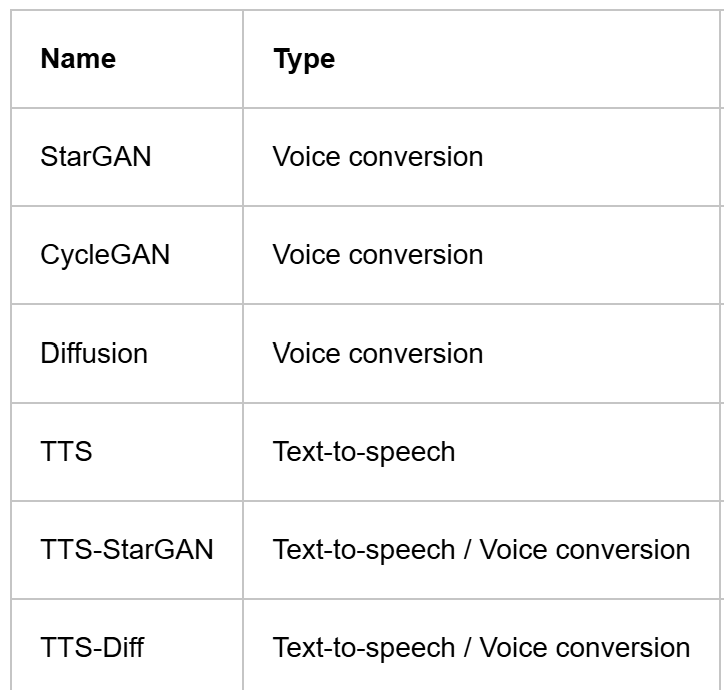

1. Los modelos de Difusión (Diff)
Con un Recall de 0.922, el modelo basado en Difusión es oficialmente el más difícil de detectar.

Por qué ? Los modelos de difusión no intentan "copiar" pedazos de audio, sino que reconstruyen la señal eliminando ruido de forma estocástica. Esto genera un audio mucho más suave, natural y con menos artefactos "robóticos" que las arquitecturas antiguas.

2. La debilidad de las GANs (StarGAN y CycleGAN)
StarGAN (0.959): Es un poco más detectable que la Difusión. Las GANs a menudo dejan pequeñas huellas de "tablero de ajedrez" (checkerboard artifacts) en el espectro debido a las capas de deconvolución.

CycleGAN (1.000): Esto suele ocurrir porque CycleGAN es una arquitectura más rígida y antigua. Probablemente genera un ruido de fase o una distorsión metálica constante que tus MFCCs identifican sin dudarlo.

3. La perfección en los TTS (Recall 1.0)
El hecho de que tengas un 1.000 (100% de éxito) en todos los modelos de Text-to-Speech (TTS) es una señal de doble filo:

La buena noticia: Tu modelo es un muro infranqueable contra voces generadas desde texto.

La sospecha: Un 1.0 perfecto a veces indica que los audios de TTS tienen una característica digital muy obvia (como ausencia total de ruido de fondo, una frecuencia de muestreo distinta o un filtrado de frecuencias muy agresivo por encima de los 8kHz). Es posible que el Random Forest esté aprendiendo a detectar "calidad de estudio digital" en lugar de "voz artificial".

4. Conclusión para tu investigación
Tu modelo es excelente para detectar técnicas de conversión de voz y síntesis clásica, pero la difusión probabilística es su "punto ciego" relativo.

Mi sugerencia:
Si quieres intentar bajar ese 0.92 de Diff y acercarlo al 1.0, deberías mirar los MFCCs de orden superior (9 al 12) o incluso calcular la Kurtosis (curtosis) de los coeficientes, ya que la difusión tiende a generar distribuciones de datos mucho más cercanas a la normal (gaussiana) que las voces humanas, que son más "caóticas".

# 4. Carga csv acentos peruanos

In [68]:
# Ruta de la carpeta Dany
ruta_peruano = "/content/drive/MyDrive/Reto_Telefonica/All_3_csv/Csv_solo_peruano/"

In [69]:
# Buscar todos los CSV
archivos = glob.glob(ruta_peruano + "*.csv")

print("CSV encontrados:")
for a in archivos:
    print(a)

dfs_peruanos = []

for archivo in archivos:

    # Leer CSV
    df_peruano = pd.read_csv(archivo)

    # Nombre del archivo
    nombre = os.path.basename(archivo).lower().strip()

    # LABEL
    if "real" in nombre:
        df_peruano["label"] = 0
    else:
        df_peruano["label"] = 1

    # ACCENT
    df_peruano["accent"] = "peruano"

    # GENERO
    if "genero_f" in df_peruano.columns:
        df_peruano["genero"] = np.where(
            df_peruano["genero_f"] == 1,
            "femenino",
            "masculino"
        )
    else:
        print("Warning: 'genero_f' no encontrada")
        df_peruano["genero"] = "unknown"

    # MODELO GENERADOR
    df_peruano["modelo_generador"] = "real"

    if df_peruano["label"].iloc[0] == 1:

        archivo_lower = df_peruano["archivo"].astype(str).str.lower()

        df_peruano.loc[
            archivo_lower.str.contains("tts-stargan", na=False),
            "modelo_generador"
        ] = "TTS-StarGAN"

        df_peruano.loc[
            archivo_lower.str.contains("tts-diff", na=False),
            "modelo_generador"
        ] = "TTS-Diff"

        df_peruano.loc[
            archivo_lower.str.contains("cyclegan", na=False),
            "modelo_generador"
        ] = "CycleGAN"

        df_peruano.loc[
            archivo_lower.str.contains("stargan", na=False)
            & ~archivo_lower.str.contains("tts-stargan", na=False),
            "modelo_generador"
        ] = "StarGAN"

        df_peruano.loc[
            archivo_lower.str.contains("diff", na=False)
            & ~archivo_lower.str.contains("tts-diff", na=False),
            "modelo_generador"
        ] = "Diff"

        df_peruano.loc[
            archivo_lower.str.contains("tts", na=False)
            & ~archivo_lower.str.contains("tts-stargan", na=False)
            & ~archivo_lower.str.contains("tts-diff", na=False),
            "modelo_generador"
        ] = "TTS"

    # Guardar dataframe
    dfs_peruanos.append(df_peruano)

# UNIR TODO
df_peruano_unified = pd.concat(dfs_peruanos, ignore_index=True)

print("\nShape final:")
print(df_peruano_unified.shape)

print("\nModelos:")
print(df_peruano_unified["modelo_generador"].value_counts())

df_peruano_unified.head()

CSV encontrados:
/content/drive/MyDrive/Reto_Telefonica/All_3_csv/Csv_solo_peruano/500peruano_dataset_features_sintetico.csv
/content/drive/MyDrive/Reto_Telefonica/All_3_csv/Csv_solo_peruano/500peruano_dataset_features_real.csv

Shape final:
(1000, 592)

Modelos:
modelo_generador
real           500
Diff           160
CycleGAN        90
StarGAN         90
TTS             80
TTS-StarGAN     40
TTS-Diff        40
Name: count, dtype: int64


,id_audio,archivo,label,genero_f,colombiano,chileno,argentino,peruano,modelo_cyclegan,modelo_diff,...,rolloff_median,rolloff_q1,rolloff_q3,rolloff_skew,rolloff_kurtosis,rolloff_mode,rolloff_iqr,accent,genero,modelo_generador
0,1,CycleGAN-pef_08421_00042078409-pef_01208_01247...,1,1,0,0,0,1,1,0,...,4761.71875,1335.937500,5916.015625,-0.121171,-1.659926,492.1875,4580.078125,peruano,femenino,CycleGAN
1,2,CycleGAN-pef_08421_00042078409-pef_03397_00805...,1,1,0,0,0,1,1,0,...,4093.75000,1810.546875,5324.218750,-0.099164,-1.290338,539.0625,3513.671875,peruano,femenino,CycleGAN
2,3,CycleGAN-pef_08421_00042078409-pef_07049_01353...,1,1,0,0,0,1,1,0,...,3882.81250,1744.140625,4939.453125,0.010095,-1.072997,515.6250,3195.312500,peruano,femenino,CycleGAN
3,4,CycleGAN-pef_08421_00042078409-pef_07508_01611...,1,1,0,0,0,1,1,0,...,4777.34375,2335.937500,5556.640625,-0.394409,-1.091107,531.2500,3220.703125,peruano,femenino,CycleGAN
4,5,CycleGAN-pef_08421_00569156593-pef_01208_01958...,1,1,0,0,0,1,1,0,...,2808.59375,1208.984375,5906.250000,0.294378,-1.419423,507.8125,4697.265625,peruano,femenino,CycleGAN


# 5. Prueba del modelo Random Forest con el csv de acentos peruanos

In [70]:
# 1. Separar X e y peruano

y_peruano = df_peruano_unified["label"]

X_peruano = df_peruano_unified.drop(columns=[
    "label",
    "archivo",
    "id_audio",
    "accent",
    "colombiano",
    "chileno",
    "argentino",
    "peruano",
    "modelo_cyclegan",
    "modelo_diff",
    "modelo_stargan",
    "modelo_tts_dif",
    "modelo_tts_stargan",
    "modelo_tts",
    "genero_f",
    "genero",
    "modelo_generador"
], errors="ignore")

# Dejar solo columnas numéricas
X_peruano = X_peruano.select_dtypes(include=["int64", "float64"])


# 2. Asegurar mismas columnas que X_train

X_peruano = X_peruano.reindex(columns=X_train.columns, fill_value=0)

# 3. Predecir con el modelo entrenado

y_pred_peruano = rf_model.predict(X_peruano)

# 4. Métricas generales

print("Resultados en acento peruano")
print("----------------------------")

print("Accuracy:", accuracy_score(y_peruano, y_pred_peruano))
print("Recall:", recall_score(y_peruano, y_pred_peruano))
print("Precision:", precision_score(y_peruano, y_pred_peruano))
print("F1-score:", f1_score(y_peruano, y_pred_peruano))


print("\nReporte:")
print(classification_report(
    y_peruano,
    y_pred_peruano,
    target_names=["Real", "IA"]
))

Resultados en acento peruano
----------------------------
Accuracy: 0.911
Recall: 0.996
Precision: 0.8512820512820513
F1-score: 0.9179723502304148

Reporte:
              precision    recall  f1-score   support

        Real       1.00      0.83      0.90       500
          IA       0.85      1.00      0.92       500

    accuracy                           0.91      1000
   macro avg       0.92      0.91      0.91      1000
weighted avg       0.92      0.91      0.91      1000



## 5.1. Matriz de Confusión

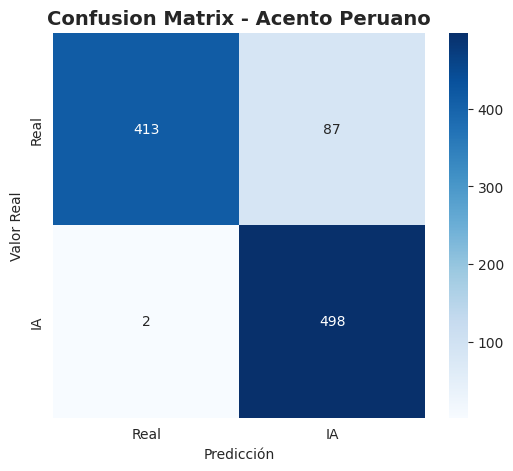

In [86]:
cm = confusion_matrix(y_peruano, y_pred_peruano)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real", "IA"],
    yticklabels=["Real", "IA"]
)

plt.title("Confusion Matrix - Acento Peruano", fontsize=14, fontweight="bold")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

# 6. Crear y entrenar XGBOOST con todos los features

In [72]:
# 1. PREPARACIÓN DE DATOS
y = df_unified["label"]

# Eliminamos metadatos para que el modelo solo aprenda de los features acústicos
X = df_unified.drop(columns=columnas_a_eliminar, errors="ignore")

In [73]:
# 2. TRAIN / TEST SPLIT
# Mantenemos el random_state=42 para poder comparar con tu Random Forest
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [74]:
# 3. CREACIÓN Y ENTRENAMIENTO DEL MODELO XGBOOST
# Configuramos parámetros iniciales robustos
xgb_model = xgb.XGBClassifier(
    n_estimators=500,           # Más árboles que RF, XGB los maneja mejor
    learning_rate=0.05,         # Paso pequeño para evitar sobreajuste
    max_depth=6,                # Profundidad típica para problemas de audio
    subsample=0.8,              # Usa el 80% de los datos por árbol para generalizar
    colsample_bytree=0.8,       # Usa el 80% de los features por árbol
    eval_metric='logloss',      # Métrica de evaluación estándar
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

print("Entrenando XGBoost...")
xgb_model.fit(X_train, y_train)
print("¡Modelo entrenado!")

Entrenando XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:46:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


¡Modelo entrenado!


In [75]:
# 4. PREDICCIONES
y_pred = xgb_model.predict(X_test)

In [76]:
# 5. CLASSIFICATION REPORT
print("\n=== REPORTE DE CLASIFICACIÓN (XGBOOST) ===")
print(classification_report(y_test, y_pred))


=== REPORTE DE CLASIFICACIÓN (XGBOOST) ===
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       300
           1       0.98      0.98      0.98       300

    accuracy                           0.98       600
   macro avg       0.98      0.98      0.98       600
weighted avg       0.98      0.98      0.98       600



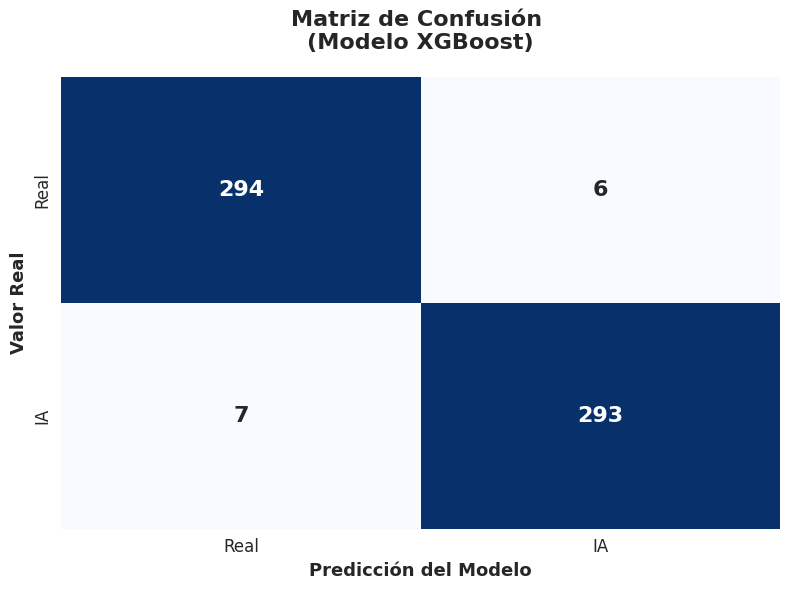

In [77]:
# 6. CONFUSION MATRIX (XGBOOST)
# Calculamos la matriz con las predicciones del modelo XGBoost
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

# Usamos annot_kws para aumentar el tamaño de los números internos
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False, # Quitamos la barra lateral para un look más limpio
    annot_kws={"size": 16, "weight": "bold"}
)

# Configuración de títulos y etiquetas
plt.title(
    "Matriz de Confusión \n(Modelo XGBoost)",
    fontsize=16,
    fontweight="bold",
    pad=20
)

# Ajuste preciso de los ejes: 0 suele ser Real y 1 es Sintético (IA)
# Centramos las etiquetas en los cuadros [0.5, 1.5]
plt.xticks([0.5, 1.5], ["Real", "IA"], fontsize=12)
plt.yticks([0.5, 1.5], ["Real", "IA"], fontsize=12, va="center")

plt.xlabel("Predicción del Modelo", fontsize=13, fontweight="bold")
plt.ylabel("Valor Real", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

In [78]:
# 7. FEATURE IMPORTANCE
# Esto te dirá qué MFCCs o estadísticas están delatando a la IA
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\n=== TOP 15 FEATURES MÁS IMPORTANTES ===  \n Modelo XGBOOST")
display(importances.head(15))


=== TOP 15 FEATURES MÁS IMPORTANTES ===  
 Modelo XGBOOST


,feature,importance
30,mfcc_1_q1,0.018240
471,bandwidth_q3,0.017256
376,delta2_mfcc_6_iqr,0.012914
27,mfcc_1_min,0.011787
492,contrast_2_q1,0.010683
43,mfcc_2_skew,0.010409
13,rms_std,0.010308
25,mfcc_1_mean,0.009899
15,rms_max,0.009649
17,rms_q1,0.009450


/tmp/ipykernel_39906/2002252918.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


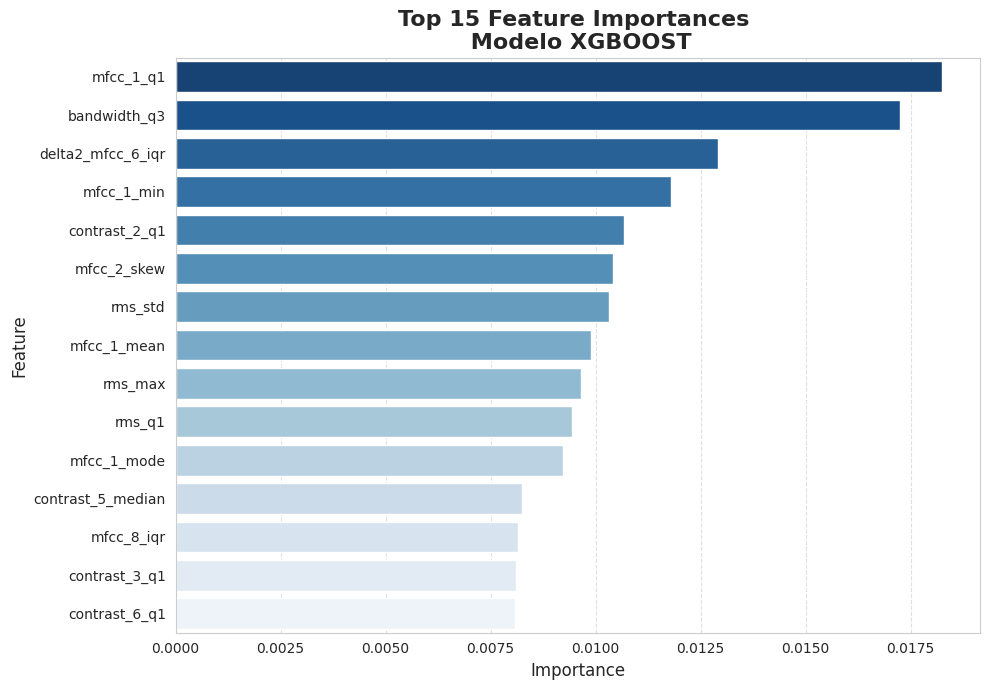

In [79]:
# 7. Generación de la Gráfica
# Seleccionamos los top 15 del dataframe que acabas de crear
top_features = importances.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature",
    palette="Blues_r"
)

plt.title(
    "Top 15 Feature Importances \n Modelo XGBOOST",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)

# Añadimos una cuadrícula sutil para facilitar la lectura
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 6.1. Recall por acentos

In [80]:
# 1. Preparación de datos

# Extraemos los acentos
accent_values = df_unified["accent"]

# 2. Split Sincronizado
# Re-ejecutamos el split para que accent_test coincida con X_test e y_test
# Importante: mantenemos el random_state=42 para que los resultados sean comparables
X_train, X_test, y_train, y_test, accent_train, accent_test = train_test_split(
    X, y, accent_values, test_size=0.2, stratify=y, random_state=42
)

# 3. Predicciones con XGBOOST en el modelo ya entrenado
y_pred = xgb_model.predict(X_test)

# 4. Crear DataFrame de resultados para facilitar el análisis por grupos
results_accent_df = pd.DataFrame({
    "accent": accent_test,
    "real": y_test,
    "pred": y_pred
})

print("=== ANÁLISIS DE RECALL POR ACENTO (XGBOOST - DETECCIÓN DE SINTÉTICOS) ===\n")

# Definimos la etiqueta para audios sintéticos (Clase Positiva)
etiqueta_sintetico = 1

# Iteramos para mostrar el reporte detallado por cada acento
for acc in results_accent_df["accent"].unique():
    subset = results_accent_df[results_accent_df["accent"] == acc]

    # Calculamos el recall específico para este acento
    rec_sintetico = recall_score(subset["real"], subset["pred"], pos_label=etiqueta_sintetico)

    print(f"--- Acento: {str(acc).upper()} ---")
    print(f"Cantidad de audios en test: {len(subset)}")
    print(f"Recall (Detección de Sintéticos): {rec_sintetico:.4f}")
    print("\nReporte detallado:")
    print(classification_report(subset["real"], subset["pred"]))
    print("-" * 40)

# 5. RESUMEN FINAL COMPARATIVO
# Agrupamos por acento y calculamos el recall de la clase sintética
resumen_acentos = results_accent_df.groupby("accent").apply(
    lambda x: recall_score(x["real"], x["pred"], pos_label=etiqueta_sintetico),
    include_groups=False
).sort_values(ascending=False)

print("\nResumen de Recall (Sintéticos) por acento con XGBoost:")
print(resumen_acentos)

=== ANÁLISIS DE RECALL POR ACENTO (XGBOOST - DETECCIÓN DE SINTÉTICOS) ===

--- Acento: COLOMBIANO ---
Cantidad de audios en test: 184
Recall (Detección de Sintéticos): 0.9362

Reporte detallado:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96        90
           1       0.99      0.94      0.96        94

    accuracy                           0.96       184
   macro avg       0.96      0.96      0.96       184
weighted avg       0.96      0.96      0.96       184

----------------------------------------
--- Acento: ARGENTINO ---
Cantidad de audios en test: 224
Recall (Detección de Sintéticos): 0.9908

Reporte detallado:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       115
           1       1.00      0.99      1.00       109

    accuracy                           1.00       224
   macro avg       1.00      1.00      1.00       224
weighted avg       1.00      1.00      1.00   

## 6.2. Recall por genero

In [81]:
# 1. Extraemos la columna de género (asumiendo que X e y ya existen del entrenamiento de XGBoost)
genero_values = df_unified["genero"]

# 2. Split Sincronizado (Recuperamos gen_test alineado con X_test)
X_train, X_test, y_train, y_test, gen_train, gen_test = train_test_split(
    X,
    y,
    genero_values,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 3. Predicciones con XGBOOST
# Cambiamos rf_model.predict por xgb_model.predict
y_pred = xgb_model.predict(X_test)

# 4. Crear DataFrame de resultados
results_gen_df = pd.DataFrame({
    "genero": gen_test,
    "real": y_test,
    "pred": y_pred
})

print("=== ANÁLISIS DE RECALL Y DESEMPEÑO POR GÉNERO (XGBOOST) ===\n")

etiqueta_sintetico = 1

# Iteramos sobre los valores únicos (masculino/femenino)
for g in results_gen_df["genero"].unique():
    subset = results_gen_df[results_gen_df["genero"] == g]

    rec_sintetico = recall_score(
        subset["real"],
        subset["pred"],
        pos_label=etiqueta_sintetico
    )

    print(f"--- Género: {str(g).upper()} ---")
    print(f"Cantidad de audios en test: {len(subset)}")
    print(f"Recall (Detección de audios sintéticos): {rec_sintetico:.4f}")
    print("\nReporte detallado:")
    print(classification_report(subset["real"], subset["pred"]))
    print("-" * 40)

# 5. Resumen comparativo final
resumen_genero = results_gen_df.groupby("genero").apply(
    lambda x: recall_score(x["real"], x["pred"], pos_label=etiqueta_sintetico),
    include_groups=False
).sort_values(ascending=False)

print("\nResumen de Recall (Sintéticos) por género con XGBoost:")
print(resumen_genero)

=== ANÁLISIS DE RECALL Y DESEMPEÑO POR GÉNERO (XGBOOST) ===

--- Género: FEMENINO ---
Cantidad de audios en test: 264
Recall (Detección de audios sintéticos): 0.9624

Reporte detallado:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       131
           1       0.96      0.96      0.96       133

    accuracy                           0.96       264
   macro avg       0.96      0.96      0.96       264
weighted avg       0.96      0.96      0.96       264

----------------------------------------
--- Género: MASCULINO ---
Cantidad de audios en test: 336
Recall (Detección de audios sintéticos): 0.9880

Reporte detallado:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       169
           1       0.99      0.99      0.99       167

    accuracy                           0.99       336
   macro avg       0.99      0.99      0.99       336
weighted avg       0.99      0.99      0.99     

## 6.3. Recall por modelo de generacion

In [82]:
# 1. Preparación de datos
# Extraemos la columna del modelo generador de los datos originales
modelos_values = df_unified["modelo_generador"]

# 2. Split Sincronizado (X, y, y MODELOS)
# Sincronizamos para que mod_test esté alineado con X_test e y_test
X_train, X_test, y_train, y_test, mod_train, mod_test = train_test_split(
    X,
    y,
    modelos_values,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 3. Predicciones con XGBOOST
y_pred = xgb_model.predict(X_test)

# 4. Crear DataFrame de resultados
results_mod_df = pd.DataFrame({
    "modelo_generador": mod_test,
    "real": y_test,
    "pred": y_pred
})

print("=== ANÁLISIS DE RECALL POR ARQUITECTURA GENERADORA (XGBOOST) ===\n")

etiqueta_sintetico = 1

# Filtramos los resultados para evaluar SOLO los audios sintéticos
solo_sinteticos = results_mod_df[results_mod_df["real"] == etiqueta_sintetico]

# Iteramos sobre cada modelo de IA (CycleGAN, StarGAN, Diff, etc.)
for m in solo_sinteticos["modelo_generador"].unique():
    if pd.isna(m) or m == "real" or m == "None":
        continue

    subset = solo_sinteticos[solo_sinteticos["modelo_generador"] == m]

    # Cálculo de recall: (aciertos / total del subgrupo)
    aciertos = (subset["pred"] == etiqueta_sintetico).sum()
    rec_modelo = aciertos / len(subset)

    print(f"--- Modelo de IA: {str(m).upper()} ---")
    print(f"Audios evaluados: {len(subset)}")
    print(f"Recall (Detección exitosa): {rec_modelo:.4f}")
    print("-" * 40)

# 5. Resumen final ordenado (XGBOOST)
# Menor Recall = La arquitectura que mejor engañó al XGBoost
resumen_modelos = solo_sinteticos.groupby("modelo_generador").apply(
    lambda x: (x["pred"] == etiqueta_sintetico).mean(),
    include_groups=False
).sort_values(ascending=True)

print("\nResumen de Recall por Arquitectura con XGBoost:")
print("(Menor Recall = IA más difícil de detectar)")
print(resumen_modelos)

=== ANÁLISIS DE RECALL POR ARQUITECTURA GENERADORA (XGBOOST) ===

--- Modelo de IA: DIFF ---
Audios evaluados: 83
Recall (Detección exitosa): 0.9759
----------------------------------------
--- Modelo de IA: CYCLEGAN ---
Audios evaluados: 54
Recall (Detección exitosa): 0.9630
----------------------------------------
--- Modelo de IA: TTS ---
Audios evaluados: 55
Recall (Detección exitosa): 1.0000
----------------------------------------
--- Modelo de IA: TTS-STARGAN ---
Audios evaluados: 33
Recall (Detección exitosa): 1.0000
----------------------------------------
--- Modelo de IA: STARGAN ---
Audios evaluados: 50
Recall (Detección exitosa): 0.9400
----------------------------------------
--- Modelo de IA: TTS-DIFF ---
Audios evaluados: 25
Recall (Detección exitosa): 1.0000
----------------------------------------

Resumen de Recall por Arquitectura con XGBoost:
(Menor Recall = IA más difícil de detectar)
modelo_generador
StarGAN        0.940000
CycleGAN       0.962963
Diff           

# 7. Prueba del modelo XGBOOST con el csv de acentos peruanos

In [85]:
# 1. Separar X e y del dataset peruano

y_peruano = df_peruano_unified["label"]

columnas_a_eliminar = [
    "label",
    "archivo",
    "id_audio",
    "accent",
    "colombiano",
    "chileno",
    "argentino",
    "peruano",
    "modelo_cyclegan",
    "modelo_diff",
    "modelo_stargan",
    "modelo_tts_dif",
    "modelo_tts_stargan",
    "modelo_tts",
    "genero_f",
    "genero",
    "modelo_generador"
]

X_peruano = df_peruano_unified.drop(
    columns=columnas_a_eliminar,
    errors="ignore"
)

# Dejar solo columnas numéricas
X_peruano = X_peruano.select_dtypes(include=["int64", "float64"])

# 2. Asegurar mismas columnas que X_train

X_peruano = X_peruano.reindex(
    columns=X_train.columns,
    fill_value=0
)

# 3. Predecir con el modelo XGBoost entrenado

y_pred_peruano_xgb = xgb_model.predict(X_peruano)

# 4. Métricas generales

print("RESULTADOS XGBOOST EN ACENTO PERUANO")
print("-" * 45)

print("Accuracy :", accuracy_score(y_peruano, y_pred_peruano_xgb))
print("Recall   :", recall_score(y_peruano, y_pred_peruano_xgb))
print("Precision:", precision_score(y_peruano, y_pred_peruano_xgb))
print("F1-score :", f1_score(y_peruano, y_pred_peruano_xgb))


print("\nReporte:")
print(classification_report(
    y_peruano,
    y_pred_peruano_xgb,
    target_names=["Real", "IA"]
))

RESULTADOS XGBOOST EN ACENTO PERUANO
---------------------------------------------
Accuracy : 0.923
Recall   : 0.998
Precision: 0.8678260869565217
F1-score : 0.9283720930232559

Reporte:
              precision    recall  f1-score   support

        Real       1.00      0.85      0.92       500
          IA       0.87      1.00      0.93       500

    accuracy                           0.92      1000
   macro avg       0.93      0.92      0.92      1000
weighted avg       0.93      0.92      0.92      1000



## 7.1. Matriz de Confusión

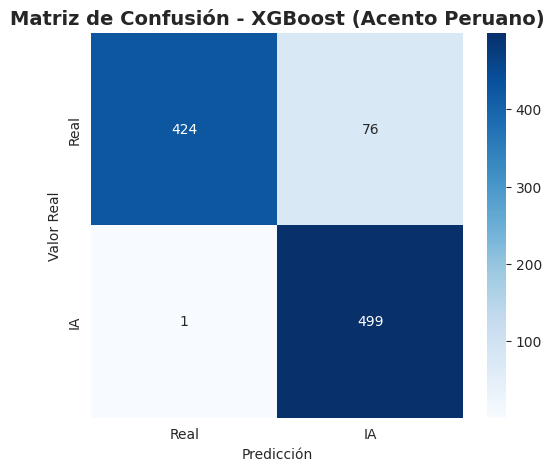

In [87]:
cm = confusion_matrix(y_peruano, y_pred_peruano_xgb)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real", "IA"],
    yticklabels=["Real", "IA"]
)

plt.title(
    "Matriz de Confusión - XGBoost (Acento Peruano)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()